# Dataset 8: Power Sector Carbon Intensity Analysis
## Overview

This notebook analyzes **Power Sector Carbon Intensity** - a critical indicator of energy transition progress and an important control variable for understanding industrial competitiveness.

### Why Power Carbon Intensity Matters

**The Indirect Carbon Cost:**
- Industries don't just face direct carbon costs (ETS allowances)
- They also pay INDIRECT costs through electricity prices
- High carbon prices → High electricity prices (merit order effect)

**The Merit Order Effect:**
1. Electricity price set by marginal generator (often gas plants)
2. Gas plants must buy ETS allowances
3. Carbon cost embedded in electricity price
4. Result: €80/tonne carbon → €100+/MWh electricity

**Carbon Intensity (gCO₂/kWh):**
- Measures how "dirty" the power sector is
- Declining intensity = Successful energy transition
- Varies by energy mix:
  * Coal-heavy (Poland): ~700 gCO₂/kWh
  * Nuclear-heavy (France): ~50 gCO₂/kWh

### Data Source

**Source:** Ember Climate Data Explorer  
**URL:** https://ember-climate.org/data/data-catalogue/  
**Unit:** grams CO₂ per kilowatt-hour  
**Coverage:** Annual, all EU countries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
DATA_PATH = '../../data/raw/'
COUNTRIES = {'DE': 'Germany', 'FR': 'France', 'IT': 'Italy', 'PL': 'Poland', 'ES': 'Spain', 'NL': 'Netherlands'}

### Load power carbon intensity data

In [2]:
df_power = pd.read_csv(f'{DATA_PATH}power_carbon_intensity.csv')
df_carbon = pd.read_csv(f'{DATA_PATH}eu_ets_carbon_prices.csv')
display(df_power.head(10))

✓ Power intensity data loaded: (90, 4)


,country_code,country,year,carbon_intensity_gco2_kwh
0,DE,Germany,2010,461
1,DE,Germany,2011,468
2,DE,Germany,2012,484
3,DE,Germany,2013,489
4,DE,Germany,2014,471
5,DE,Germany,2015,468
6,DE,Germany,2016,453
7,DE,Germany,2017,436
8,DE,Germany,2018,422
9,DE,Germany,2019,369


### Power sector carbon intensity evolution

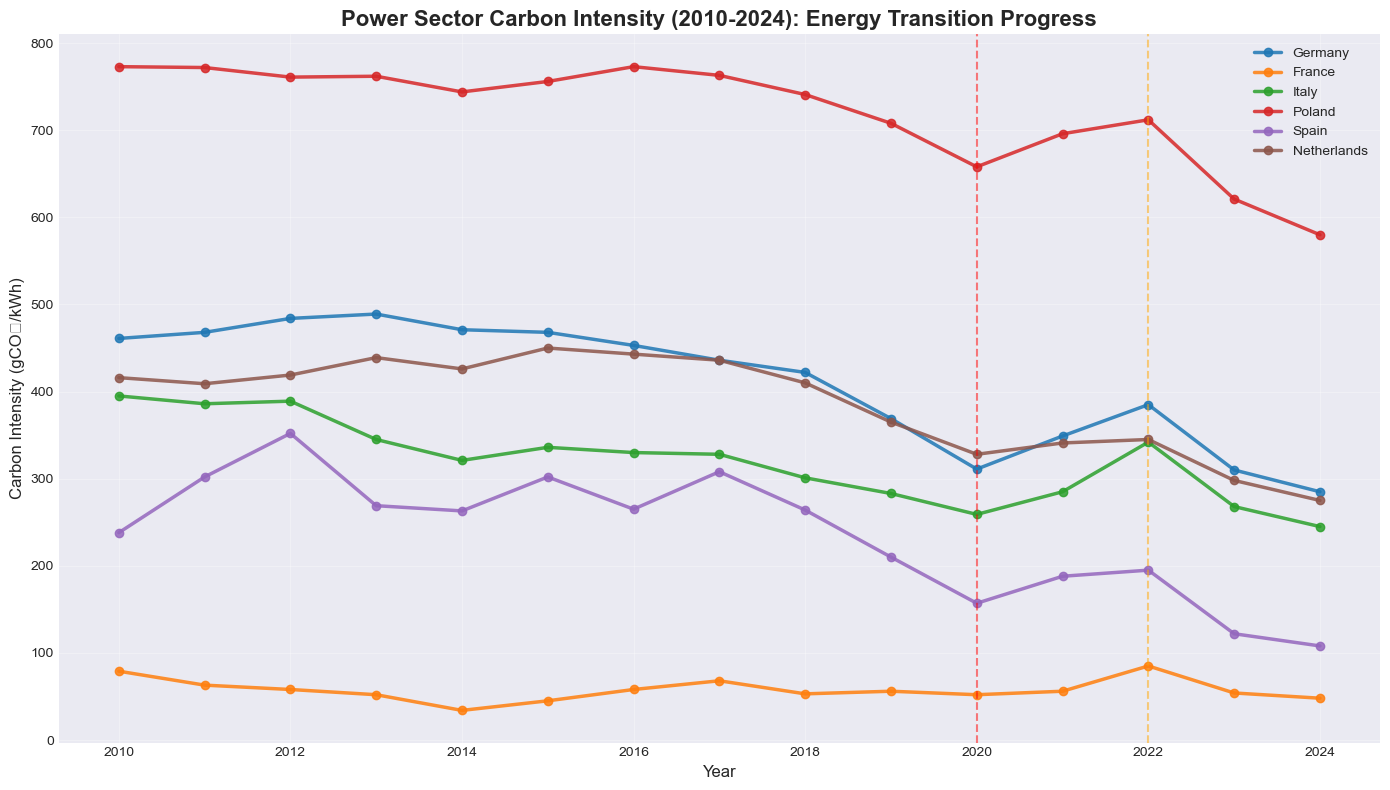

In [4]:
plt.figure(figsize=(14, 8))

for country in COUNTRIES.values():
    data = df_power[df_power['country'] == country]
    plt.plot(data['year'], data['carbon_intensity_gco2_kwh'], 
             marker='o', linewidth=2.5, label=country, alpha=0.85)

plt.title('Power Sector Carbon Intensity (2010-2024): Energy Transition Progress', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Carbon Intensity (gCO₂/kWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.axvline(x=2020, color='red', linestyle='--', alpha=0.5, label='COVID-19')
plt.axvline(x=2022, color='orange', linestyle='--', alpha=0.5, label='Energy Crisis')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### KEY OBSERVATIONS:
1. POLAND: Highest intensity (~700 gCO₂/kWh) - coal-dependent
2. FRANCE: Lowest intensity (~50 gCO₂/kWh) - nuclear dominance
3. GERMANY: High baseline, strong decline (coal → renewables)
4. 2022 SPIKE: Energy crisis → return to coal/gas
5. 2023-2024: Renewed decline (renewables expansion)

### Decarbonization rate

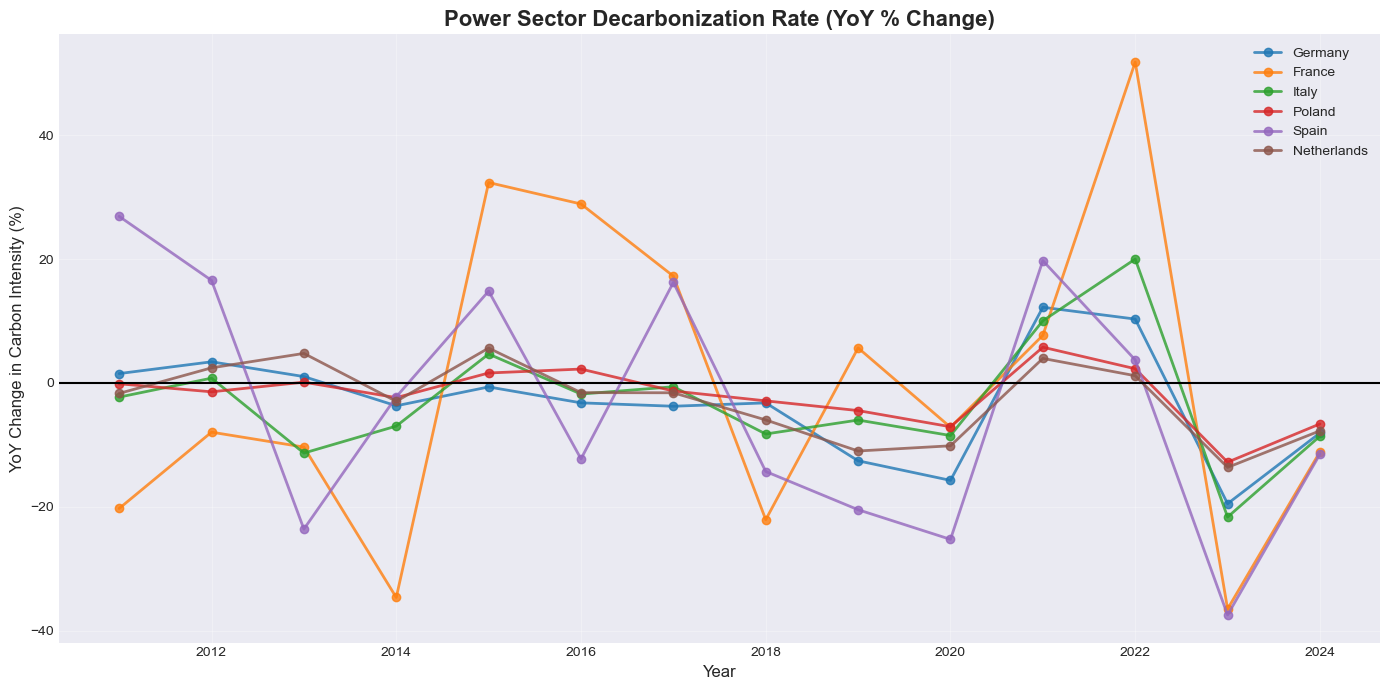

Negative values = decarbonization progress
Positive values = increased carbon intensity (e.g., 2022 energy crisis)


In [5]:
df_power_sorted = df_power.sort_values(['country', 'year'])
df_power_sorted['intensity_change_pct'] = df_power_sorted.groupby('country')['carbon_intensity_gco2_kwh'].pct_change() * 100

plt.figure(figsize=(14, 7))

for country in COUNTRIES.values():
    data = df_power_sorted[df_power_sorted['country'] == country]
    plt.plot(data['year'], data['intensity_change_pct'], 
             marker='o', linewidth=2, label=country, alpha=0.8)

plt.title('Power Sector Decarbonization Rate (YoY % Change)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('YoY Change in Carbon Intensity (%)', fontsize=12)
plt.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Negative values = decarbonization progress")
print("Positive values = increased carbon intensity (e.g., 2022 energy crisis)")

### 2010 vs 2024 comparison

POWER SECTOR DECARBONIZATION: 2010 vs 2024


,country,intensity_2010,intensity_2024,absolute_reduction,percent_reduction
1,Spain,238,108,130,54.62
2,France,79,48,31,39.24
0,Germany,461,285,176,38.18
3,Italy,395,245,150,37.97
4,Netherlands,416,275,141,33.89
5,Poland,773,580,193,24.97


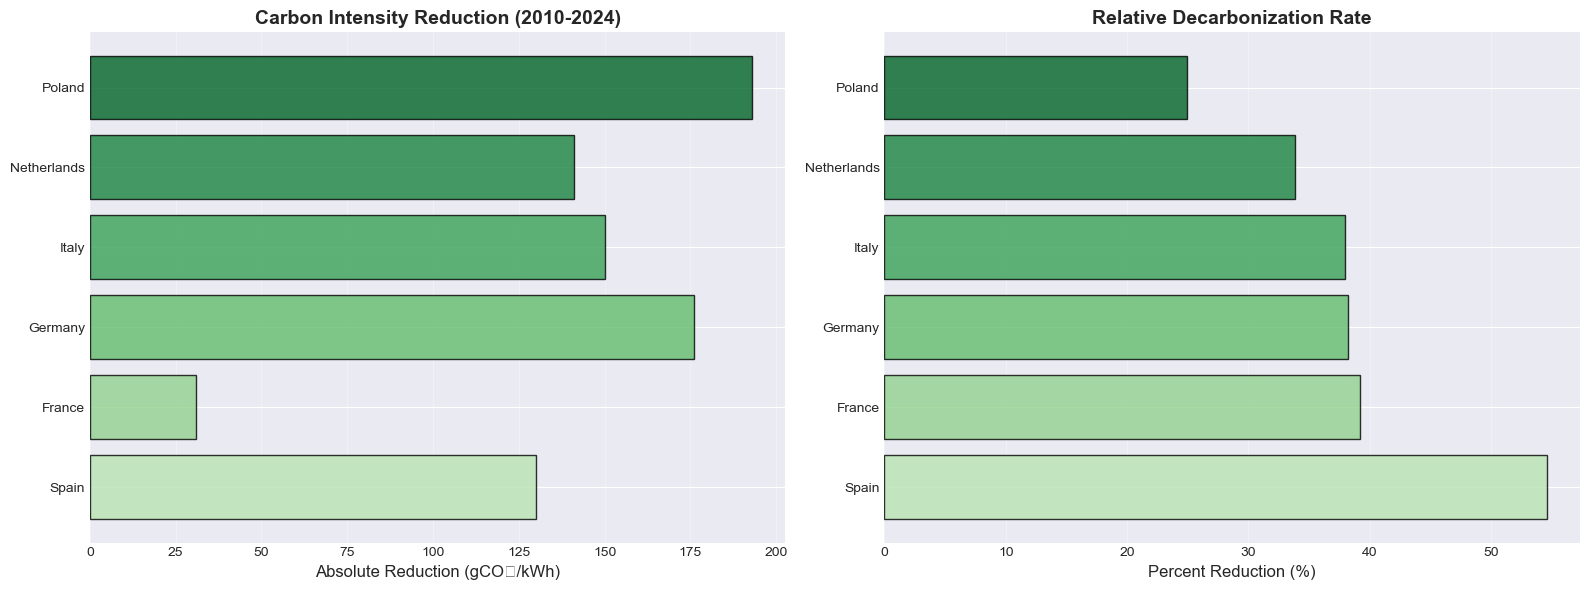

In [7]:
df_2010 = df_power[df_power['year'] == 2010][['country', 'carbon_intensity_gco2_kwh']].rename(
    columns={'carbon_intensity_gco2_kwh': 'intensity_2010'})
df_2024 = df_power[df_power['year'] == 2024][['country', 'carbon_intensity_gco2_kwh']].rename(
    columns={'carbon_intensity_gco2_kwh': 'intensity_2024'})

df_change = df_2010.merge(df_2024, on='country')
df_change['absolute_reduction'] = df_change['intensity_2010'] - df_change['intensity_2024']
df_change['percent_reduction'] = ((df_change['intensity_2010'] - df_change['intensity_2024']) / 
                                   df_change['intensity_2010'] * 100).round(2)
df_change = df_change.sort_values('percent_reduction', ascending=False)

print("=" * 80)
print("POWER SECTOR DECARBONIZATION: 2010 vs 2024")
print("=" * 80)
display(df_change)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute reduction
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(df_change)))
axes[0].barh(df_change['country'], df_change['absolute_reduction'], 
             color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Absolute Reduction (gCO₂/kWh)', fontsize=12)
axes[0].set_title('Carbon Intensity Reduction (2010-2024)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Percent reduction
axes[1].barh(df_change['country'], df_change['percent_reduction'], 
             color=colors, alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Percent Reduction (%)', fontsize=12)
axes[1].set_title('Relative Decarbonization Rate', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### WINNERS:
- Germany: Massive absolute reduction (~180 gCO2/kWh)
- Spain: Strong relative reduction (~55%)
- Netherlands: Significant progress

LAGGARDS:
- France: Small change (already very low baseline)
- Poland: Modest reduction (still very high absolute level)

### Correlation: Carbon price vs Power decarbonization

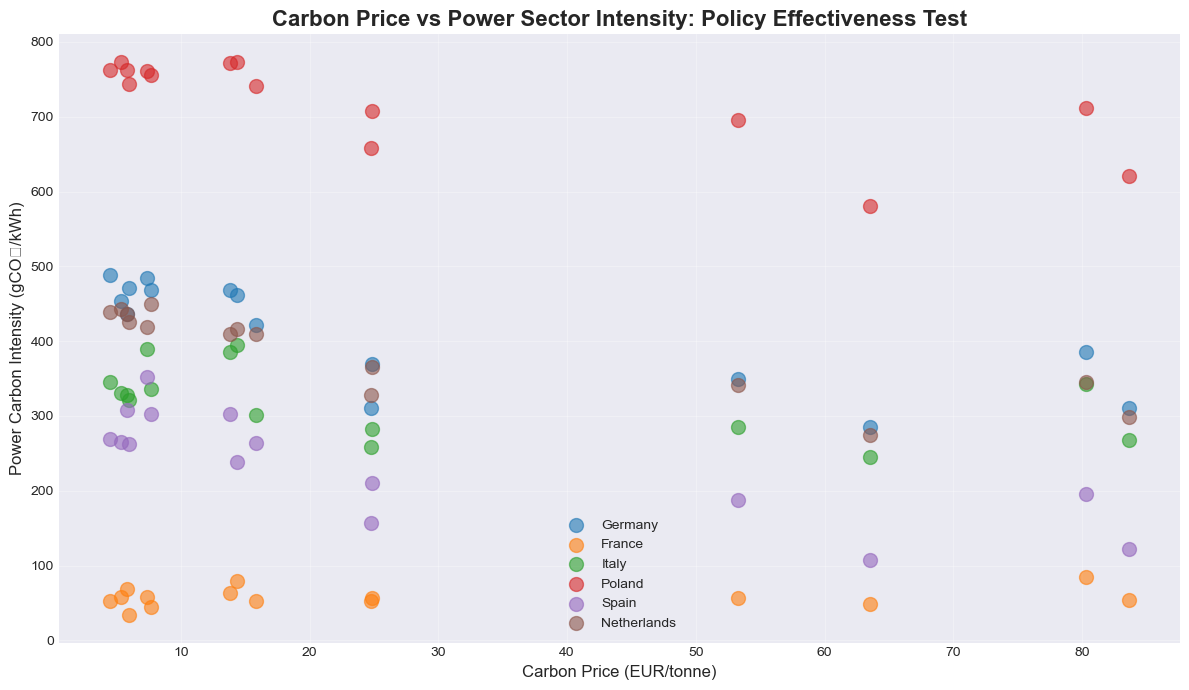


Correlation Analysis:
Germany     : -0.776
France      : +0.243
Italy       : -0.506
Poland      : -0.772
Spain       : -0.801
Netherlands : -0.866


In [8]:
df_combined = df_power.merge(df_carbon[['year', 'carbon_price_eur_tonne']], on='year', how='left')

plt.figure(figsize=(12, 7))

for country in COUNTRIES.values():
    data = df_combined[df_combined['country'] == country]
    plt.scatter(data['carbon_price_eur_tonne'], data['carbon_intensity_gco2_kwh'], 
               s=100, alpha=0.6, label=country)

plt.title('Carbon Price vs Power Sector Intensity: Policy Effectiveness Test', fontsize=16, fontweight='bold')
plt.xlabel('Carbon Price (EUR/tonne)', fontsize=12)
plt.ylabel('Power Carbon Intensity (gCO₂/kWh)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCorrelation Analysis:")
for country in COUNTRIES.values():
    data = df_combined[df_combined['country'] == country].dropna()
    if len(data) > 0:
        corr = data['carbon_price_eur_tonne'].corr(data['carbon_intensity_gco2_kwh'])
        print(f"{country:12s}: {corr:+.3f}")

### INTERPRETATION:
Expected: Negative correlation (higher prices → cleaner power)

If positive correlation found:
- Could indicate reverse causality (dirty power → high prices)
- Or confounding by energy crisis (2022: high prices + dirty backup generation)

This highlights the need for careful econometric modeling!

### Indirect carbon cost calculation
### Assumption: Average industrial electricity consumption = 1000 kWh per EUR of GVA

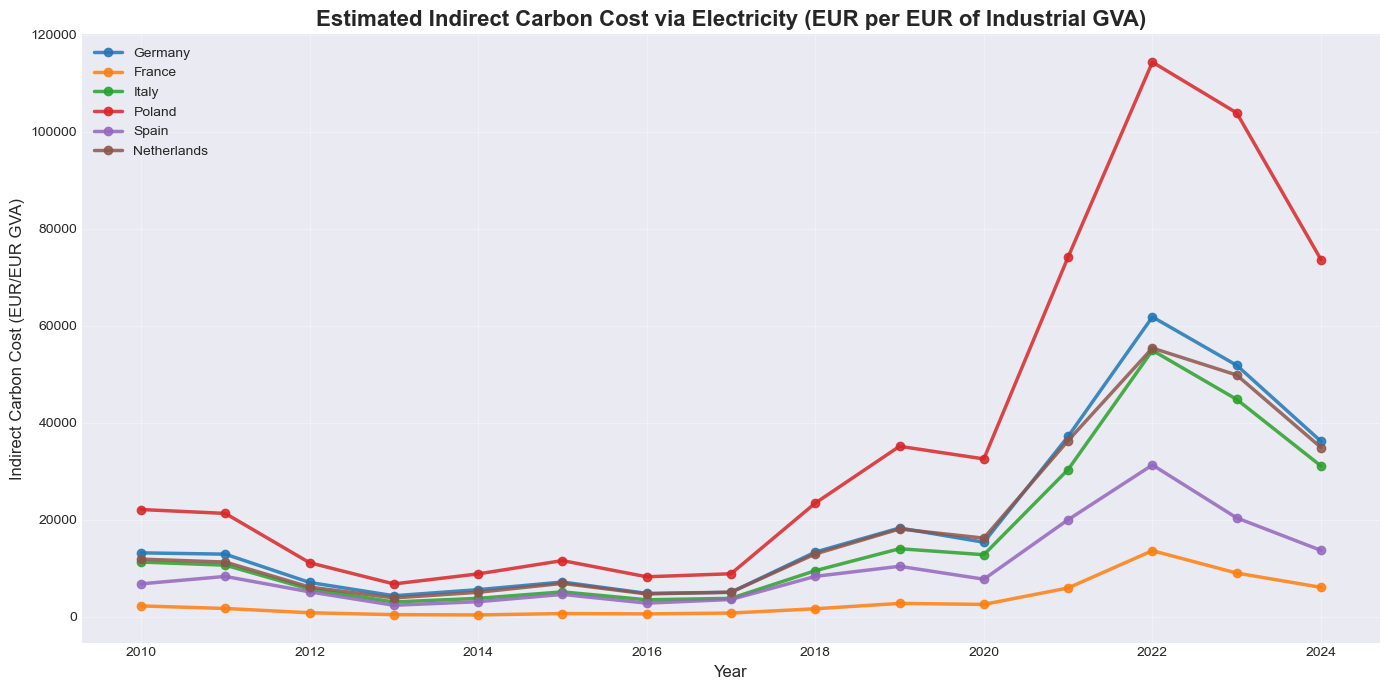

In [9]:
try:
    df_gva = pd.read_csv(f'{DATA_PATH}eurostat_gva.csv')
    
    df_full = df_combined.merge(df_gva[['country_code', 'year', 'gva_industry_meur']], 
                                 on=['country_code', 'year'], how='left')
    
    # Estimate indirect carbon cost (simplified)
    # Industry electricity intensity assumed ~2 MWh per EUR
    df_full['indirect_carbon_cost_eur'] = (
        df_full['carbon_intensity_gco2_kwh'] / 1000 *  # Convert to kg CO₂/kWh
        df_full['carbon_price_eur_tonne'] *  # EUR per tonne
        2000  # kWh per EUR of GVA (assumed)
    )
    
    plt.figure(figsize=(14, 7))
    
    for country in COUNTRIES.values():
        data = df_full[df_full['country'] == country]
        plt.plot(data['year'], data['indirect_carbon_cost_eur'], 
                 marker='o', linewidth=2.5, label=country, alpha=0.85)
    
    plt.title('Estimated Indirect Carbon Cost via Electricity (EUR per EUR of Industrial GVA)', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Indirect Carbon Cost (EUR/EUR GVA)', fontsize=12)
    plt.legend(loc='upper left', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("""""")
    
except FileNotFoundError:
    print("Error")

### INDIRECT COST BURDEN:
    This shows the hidden carbon cost embedded in electricity prices.
    
    Poland suffers most due to:
    1. High power carbon intensity (coal-heavy)
    2. High carbon prices
    
    France benefits from nuclear (low carbon intensity)
    
    This explains different competitiveness impacts across countries!

## Key Findings

1. **Successful Decarbonization:** All countries reduced power sector carbon intensity (2010-2024)

2. **Heterogeneous Baselines:**
   - Poland: ~580 gCO₂/kWh (2024) - coal-dependent
   - France: ~48 gCO₂/kWh (2024) - nuclear advantage

3. **Energy Crisis Impact:** 2022 spike shows vulnerability to gas supply shocks

4. **Indirect Cost Burden:**
   - Coal-heavy countries face DOUBLE burden:
     * Direct: ETS compliance costs
     * Indirect: High electricity prices
   - This amplifies competitiveness disadvantage

5. **Policy Effectiveness:** Declining intensity suggests carbon pricing drives power sector transition

### Research Implications

**For Econometric Model:**
- MUST include power carbon intensity as control variable
- Captures indirect carbon cost transmission
- Explains country heterogeneity in industrial impact

**For Goal 1 (Regulatory Drag):**
- Countries with dirty power grids suffer MORE from high carbon prices
- Poland's industrial decline may be explained by double burden

**For Goal 2 (Porter Hypothesis):**
- Power sector shows SUCCESSFUL innovation response
- Renewables deployment accelerated under high carbon prices
- But: Does this extend to manufacturing industry?

**Critical Insight:**
The same carbon price creates DIFFERENT burdens across countries due to power sector carbon intensity.

---

## Project Conclusion

We have now analyzed ALL eight core datasets:

1. Eurostat GVA (Industrial Output)
2. Eurostat PPI (Inflation Control)
3. EU ETS Carbon Prices (Policy Intervention)
4. GHG Emissions (Environmental Outcome)
5. EU ETS Compliance (Effective Carbon Cost)
6. Industrial Production Index
7. Energy Consumption
8. Power Carbon Intensity (Indirect Cost)

**Next Steps:**
1. Merge all datasets into a unified panel (download_complete_data.py already does this)
2. Perform econometric analysis (fixed-effects regression)
3. Test research hypotheses:
   - H1: Regulatory Drag
   - H2: Porter Hypothesis
   - H3: Valley of Death